# Data Preparation: Jalur Irisan 3 Kelas
### Standardisasi, Deduplikasi, dan Pemisahan Data Bebas Kebocoran Lesi

Notebook ini melanjutkan hasil dari tahap Data Understanding untuk menyiapkan dataset siap latih:
1. Memindai citra fisik (.jpg) dari ketiga dataset sumber (HAM10000, ISIC 2019, dan ISIC 2017).
2. Membersihkan citra duplikat dengan prioritas benchmark HAM10000 dipertahankan 100% utuh.
3. Menyeragamkan label diagnosis (harmonisasi medis) dan mengambil irisan 3 kelas bersama (NV, MEL, BKL).
4. Memvalidasi total 22.051 citra bersih dan memetakan target integer (NV=0, MEL=1, BKL=2).
5. Membagi data menjadi Train (80%), Val (10%), dan Test (10%) berbasis lesion_id (Stratified Group K-Fold) guna menjamin 100% bebas kebocoran lesi pasien.

## Langkah 1: Setup Library dan Konfigurasi Sumber Dataset
Menyiapkan pustaka Python yang dibutuhkan dan mengonfigurasi jalur lokasi 5 partisi data dari HAM10000, ISIC 2019, dan ISIC 2017.

In [10]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 110

current_dir = os.getcwd()
candidates = [
    os.path.join(current_dir, 'Dataset'),
    os.path.join(os.path.dirname(current_dir), 'Dataset'),
    os.path.join(os.path.dirname(os.path.dirname(current_dir)), 'Dataset'),
    r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"
]

ROOT = None
for cand in candidates:
    if os.path.exists(cand):
        ROOT = cand
        break

if ROOT is None:
    raise FileNotFoundError("Folder Dataset tidak ditemukan!")

print(f"Folder Dataset terdeteksi: {ROOT}")

SOURCES = {
    'ham10000': {
        'nama': 'HAM10000 (ViDIR Austria & Queensland Australia)',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
        'fmt': 'ham_dx'
    },
    'isic_2019_train': {
        'nama': 'ISIC 2019 Training Input (BCN-20000 + ViDIR + HAM10k Overlap)',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
        'fmt': 'onehot9'
    },
    'isic_2017_train': {
        'nama': 'ISIC 2017 Training Data',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv'),
        'fmt': '2017'
    },
    'isic_2017_val': {
        'nama': 'ISIC 2017 Validation Data',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv'),
        'fmt': '2017'
    },
    'isic_2017_test': {
        'nama': 'ISIC 2017 Test Data (v2)',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv'),
        'fmt': '2017'
    }
}

print("\nDaftar 5 partisi sumber data yang dikonfigurasi:")
for k, v in SOURCES.items():
    print(f"- {k}: {v['nama']}")

Folder Dataset terdeteksi: c:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset

Daftar 5 partisi sumber data yang dikonfigurasi:
- ham10000: HAM10000 (ViDIR Austria & Queensland Australia)
- isic_2019_train: ISIC 2019 Training Input (BCN-20000 + ViDIR + HAM10k Overlap)
- isic_2017_train: ISIC 2017 Training Data
- isic_2017_val: ISIC 2017 Validation Data
- isic_2017_test: ISIC 2017 Test Data (v2)


## Langkah 2: Pemindaian File Gambar Fisik dan Ground Truth
Memeriksa file citra (.jpg) di disk dan memasangkan label diagnosis ground truth asli dari tiap file CSV.

In [11]:
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(d, f)
                        })
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(root_dir, f)
                        })

df_images = pd.DataFrame(all_images)

gt_records = {}

# HAM10000
df_ham = pd.read_csv(SOURCES['ham10000']['gt_path'])
gt_records['ham10000'] = dict(zip(df_ham['image_id'], df_ham['dx'].str.lower()))

# ISIC 2019
df_19 = pd.read_csv(SOURCES['isic_2019_train']['gt_path'])
cols_19 = [c for c in df_19.columns if c not in ('image', 'score_weight', 'validation_weight')]
gt_19 = {}
for _, r in df_19.iterrows():
    for c in cols_19:
        if r[c] == 1.0:
            gt_19[r['image']] = c
            break
gt_records['isic_2019_train'] = gt_19

# ISIC 2017 (Train, Val, Test)
for s in ['isic_2017_train', 'isic_2017_val', 'isic_2017_test']:
    df_17 = pd.read_csv(SOURCES[s]['gt_path'])
    id_col = 'image_id' if 'image_id' in df_17.columns else df_17.columns[0]
    gt_17 = {}
    for _, r in df_17.iterrows():
        img_id = str(r[id_col]).replace('.jpg', '')
        if r.get('melanoma') == 1.0:
            gt_17[img_id] = 'melanoma'
        elif r.get('seborrheic_keratosis') == 1.0:
            gt_17[img_id] = 'seborrheic_keratosis'
        else:
            gt_17[img_id] = 'nevus'
    gt_records[s] = gt_17

df_images['original_label'] = df_images.apply(
    lambda r: gt_records.get(r['source'], {}).get(r['image_id'], np.nan), axis=1
)

print(f"Total citra fisik terindeks dari seluruh sumber: {len(df_images):,} citra")
for src in SOURCES.keys():
    sub = df_images[df_images['source'] == src]
    print(f"- {src}: {len(sub):,} citra fisik ({sub['original_label'].notna().sum():,} memiliki label)")

Total citra fisik terindeks dari seluruh sumber: 38,096 citra
- ham10000: 10,015 citra fisik (10,015 memiliki label)
- isic_2019_train: 25,331 citra fisik (25,331 memiliki label)
- isic_2017_train: 2,000 citra fisik (2,000 memiliki label)
- isic_2017_val: 150 citra fisik (150 memiliki label)
- isic_2017_test: 600 citra fisik (600 memiliki label)


## Langkah 3: Pembersihan Gambar Duplikat (Deduplikasi Data)
Membersihkan citra kembar antar-dataset dengan mempertahankan HAM10000 100% utuh serta membuang duplikat pada ISIC 2019 dan 2017.

In [12]:
PRIORITY_ORDER = [
    'ham10000',
    'isic_2019_train',
    'isic_2017_train',
    'isic_2017_val',
    'isic_2017_test'
]
priority_rank = {src: i for i, src in enumerate(PRIORITY_ORDER)}

df_all = df_images.copy()
df_all['priority'] = df_all['source'].map(priority_rank)

df_sorted = df_all.sort_values(by=['image_id', 'priority'])
df_clean = df_sorted.drop_duplicates(subset='image_id', keep='first').copy()
df_dropped = df_sorted[~df_sorted.index.isin(df_clean.index)].copy()

kept_map = df_clean.set_index('image_id')['source'].to_dict()
df_dropped['kept_in_source'] = df_dropped['image_id'].map(kept_map)

before_counts = df_all['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows_ba = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    
    dropped_src = df_dropped[df_dropped['source'] == src]
    if len(dropped_src) > 0:
        kept_counts = dropped_src['kept_in_source'].value_counts()
        detail_kept = "; ".join([f"{k} ({v:,})" for k, v in kept_counts.items()])
    else:
        detail_kept = "- (Data primer utuh)"
        
    rows_ba.append({
        'Source Dataset': src,
        'Before (Awal)': f"{b:,}",
        'Duplikat Dihapus': f"{d:,}",
        'Duplikat dengan Dataset Mana': detail_kept,
        'After (Bersih Unik)': f"{a:,}",
        'Persentase Bertahan': f"{a/b*100:.1f}%"
    })

df_ba_table = pd.DataFrame(rows_ba)
display(df_ba_table)

print(f"Total citra awal             : {len(df_all):,} citra")
print(f"Total duplikat dibuang       : {len(df_dropped):,} citra")
print(f"Total citra unik bersih      : {len(df_clean):,} citra")

,Source Dataset,Before (Awal),Duplikat Dihapus,Duplikat dengan Dataset Mana,After (Bersih Unik),Persentase Bertahan
0,ham10000,"10,015",0,- (Data primer utuh),"10,015",100.0%
1,isic_2019_train,"25,331","10,015","ham10000 (10,015)","15,316",60.5%
2,isic_2017_train,"2,000",717,isic_2019_train (717),"1,283",64.1%
3,isic_2017_val,150,2,isic_2019_train (2),148,98.7%
4,isic_2017_test,600,1,isic_2019_train (1),599,99.8%


Total citra awal             : 38,096 citra
Total duplikat dibuang       : 10,735 citra
Total citra unik bersih      : 27,361 citra


## Langkah 4: Harmonisasi Label Diagnosis Medis
Menyeragamkan variasi istilah diagnosis dari masing-masing dataset menjadi kode standar medis internasional (seborrheic_keratosis dilebur ke BKL sesuai ontologi medis).

In [13]:
HARMONIZATION_MAP = {
    'nv': 'NV', 'mel': 'MEL', 'bkl': 'BKL', 'bcc': 'BCC',
    'akiec': 'AKIEC', 'vasc': 'VASC', 'df': 'DF',
    'nevus': 'NV', 'melanoma': 'MEL', 'seborrheic_keratosis': 'BKL',
    'NV': 'NV', 'MEL': 'MEL', 'BKL': 'BKL', 'BCC': 'BCC',
    'AK': 'AKIEC', 'SCC': 'SCC', 'VASC': 'VASC', 'DF': 'DF'
}

MED_DESC = {
    'NV': ('Melanocytic Nevus', 'Tahi lalat jinak melanositik'),
    'MEL': ('Melanoma', 'Kanker kulit ganas melanosit'),
    'BKL': ('Benign Keratosis', 'Keratosis seboroik / lentigo surya jinak'),
    'BCC': ('Basal Cell Carcinoma', 'Karsinoma sel basal ganas'),
    'AKIEC': ('Actinic Keratosis', 'Lesi pra-kanker keratinositik'),
    'VASC': ('Vascular Lesion', 'Kelainan pembuluh darah kulit jinak'),
    'DF': ('Dermatofibroma', 'Nodul jinak jaringan ikat fibrohistiositik'),
    'SCC': ('Squamous Cell Carcinoma', 'Karsinoma sel skuamosa ganas')
}

df_clean['harmonized_label'] = df_clean['original_label'].map(HARMONIZATION_MAP)

harm_summary = []
for code, (med_name, desc) in MED_DESC.items():
    cnt_ham = len(df_clean[(df_clean['source'] == 'ham10000') & (df_clean['harmonized_label'] == code)])
    cnt_19 = len(df_clean[(df_clean['source'] == 'isic_2019_train') & (df_clean['harmonized_label'] == code)])
    cnt_17 = len(df_clean[(df_clean['source'].str.contains('isic_2017')) & (df_clean['harmonized_label'] == code)])
    tot = cnt_ham + cnt_19 + cnt_17
    
    status_irisan = "Ada di ketiga dataset (Irisan)" if (cnt_ham > 0 and cnt_19 > 0 and cnt_17 > 0) else "Gugur (Tidak ada di ISIC 2017)"
    harm_summary.append({
        'Kode': code,
        'Nama Diagnosis Medis': med_name,
        'Deskripsi Patologis': desc,
        'HAM10000': f"{cnt_ham:,}",
        'ISIC 2019 (Unik)': f"{cnt_19:,}",
        'ISIC 2017 (Unik)': f"{cnt_17:,}",
        'Total Bersih': f"{tot:,}",
        'Status Irisan 3 Dataset': status_irisan
    })

df_harm_table = pd.DataFrame(harm_summary)
display(df_harm_table)

,Kode,Nama Diagnosis Medis,Deskripsi Patologis,HAM10000,ISIC 2019 (Unik),ISIC 2017 (Unik),Total Bersih,Status Irisan 3 Dataset
0,NV,Melanocytic Nevus,Tahi lalat jinak melanositik,"6,705","6,170","1,273","14,148",Ada di ketiga dataset (Irisan)
1,MEL,Melanoma,Kanker kulit ganas melanosit,"1,113","3,409",373,"4,895",Ada di ketiga dataset (Irisan)
2,BKL,Benign Keratosis,Keratosis seboroik / lentigo surya jinak,"1,099","1,525",384,"3,008",Ada di ketiga dataset (Irisan)
3,BCC,Basal Cell Carcinoma,Karsinoma sel basal ganas,514,"2,809",0,"3,323",Gugur (Tidak ada di ISIC 2017)
4,AKIEC,Actinic Keratosis,Lesi pra-kanker keratinositik,327,737,0,"1,064",Gugur (Tidak ada di ISIC 2017)
5,VASC,Vascular Lesion,Kelainan pembuluh darah kulit jinak,142,111,0,253,Gugur (Tidak ada di ISIC 2017)
6,DF,Dermatofibroma,Nodul jinak jaringan ikat fibrohistiositik,115,124,0,239,Gugur (Tidak ada di ISIC 2017)
7,SCC,Squamous Cell Carcinoma,Karsinoma sel skuamosa ganas,0,431,0,431,Gugur (Tidak ada di ISIC 2017)


## Langkah 5: Penentuan Irisan Bersama Antar-Dataset
Mengevaluasi irisan matematika himpunan label yang dimiliki bersama oleh HAM10000, ISIC 2019, dan ISIC 2017.

In [14]:
classes_ham = set(df_clean[df_clean['source'] == 'ham10000']['harmonized_label'].unique())
classes_19 = set(df_clean[df_clean['source'] == 'isic_2019_train']['harmonized_label'].unique())
classes_17 = set(df_clean[df_clean['source'].str.contains('isic_2017')]['harmonized_label'].unique())

irisan_3kelas = sorted(list(classes_ham.intersection(classes_19).intersection(classes_17)))
dropped_classes = sorted(list((classes_ham | classes_19) - set(irisan_3kelas)))

print(f"Kelas pada HAM10000  ({len(classes_ham)} kelas) : {sorted(list(classes_ham))}")
print(f"Kelas pada ISIC 2019 ({len(classes_19)} kelas) : {sorted(list(classes_19))}")
print(f"Kelas pada ISIC 2017 ({len(classes_17)} kelas) : {sorted(list(classes_17))}")
print(f"Hasil Irisan Bersama ({len(irisan_3kelas)} kelas) : {irisan_3kelas}")
print(f"Kelas yang Gugur     ({len(dropped_classes)} kelas) : {dropped_classes}")

Kelas pada HAM10000  (7 kelas) : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
Kelas pada ISIC 2019 (8 kelas) : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
Kelas pada ISIC 2017 (3 kelas) : ['BKL', 'MEL', 'NV']
Hasil Irisan Bersama (3 kelas) : ['BKL', 'MEL', 'NV']
Kelas yang Gugur     (5 kelas) : ['AKIEC', 'BCC', 'DF', 'SCC', 'VASC']


## Langkah 6: Penyaringan 3 Kelas dan Validasi Integritas Data
Menyaring data unik pada 3 kelas terpilih, memetakan label diagnosis ke integer target (NV=0, MEL=1, BKL=2), dan memvalidasi kelengkapan data.

In [15]:
df_3kelas_final = df_clean[df_clean['harmonized_label'].isin(irisan_3kelas)].copy().reset_index(drop=True)

CLASS_MAP_3 = {
    'NV': (0, 'Melanocytic Nevus (Tahi Lalat Jinak)'),
    'MEL': (1, 'Melanoma (Kanker Ganas)'),
    'BKL': (2, 'Benign Keratosis (Keratosis Seboroik Jinak)')
}

df_3kelas_final['target_multiclass'] = df_3kelas_final['harmonized_label'].map(lambda x: CLASS_MAP_3[x][0])
df_3kelas_final['class_name'] = df_3kelas_final['harmonized_label'].map(lambda x: CLASS_MAP_3[x][1])

total_awal_unik = len(df_clean)
total_akhir_3k  = len(df_3kelas_final)
total_gugur     = total_awal_unik - total_akhir_3k

print(f"Total citra unik bersih gabungan : {total_awal_unik:,} citra")
print(f"Citra gugur (di luar 3 kelas)    : {total_gugur:,} citra ({', '.join(dropped_classes)})")
print(f"Total citra final 3 kelas        : {total_akhir_3k:,} citra (Target validasi: tepat 22.051)")
print(f"Missing Values pada target       : {df_3kelas_final['target_multiclass'].isna().sum()} baris")
assert total_akhir_3k == 22051, f"Validasi gagal! Jumlah baris {total_akhir_3k} != 22051"
print("Validasi integritas sukses tepat 22.051 citra!")

print("\nContoh 10 baris pertama data final:")
display(df_3kelas_final[['image_id', 'source', 'original_label', 'harmonized_label', 'target_multiclass', 'class_name']].head(10))

Total citra unik bersih gabungan : 27,361 citra
Citra gugur (di luar 3 kelas)    : 5,310 citra (AKIEC, BCC, DF, SCC, VASC)
Total citra final 3 kelas        : 22,051 citra (Target validasi: tepat 22.051)
Missing Values pada target       : 0 baris
Validasi integritas sukses tepat 22.051 citra!

Contoh 10 baris pertama data final:


,image_id,source,original_label,harmonized_label,target_multiclass,class_name
0,ISIC_0000000,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
1,ISIC_0000001,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
2,ISIC_0000002,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas)
3,ISIC_0000003,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
4,ISIC_0000004,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas)
5,ISIC_0000006,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
6,ISIC_0000007,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
7,ISIC_0000008,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
8,ISIC_0000009,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
9,ISIC_0000010,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)


## Langkah 7: Visualisasi Distribusi 3 Kelas Hasil Irisan
Menampilkan tabel rekapitulasi data dan 2 grafik batang: sebaran total 3 kelas gabungan serta perbandingan kontribusi per sumber dataset.

,Source Dataset,Total Citra,NV (Nevus),MEL (Melanoma),BKL (Keratosis)
0,ham10000,"8,917","6,705 (75.2%)","1,113 (12.5%)","1,099 (12.3%)"
1,isic_2019_train,"11,104","6,170 (55.6%)","3,409 (30.7%)","1,525 (13.7%)"
2,isic_2017_train,"1,283",804 (62.7%),227 (17.7%),252 (19.6%)
3,isic_2017_val,148,76 (51.4%),30 (20.3%),42 (28.4%)
4,isic_2017_test,599,393 (65.6%),116 (19.4%),90 (15.0%)
5,TOTAL KESELURUHAN,"22,051","14,148 (64.2%)","4,895 (22.2%)","3,008 (13.6%)"


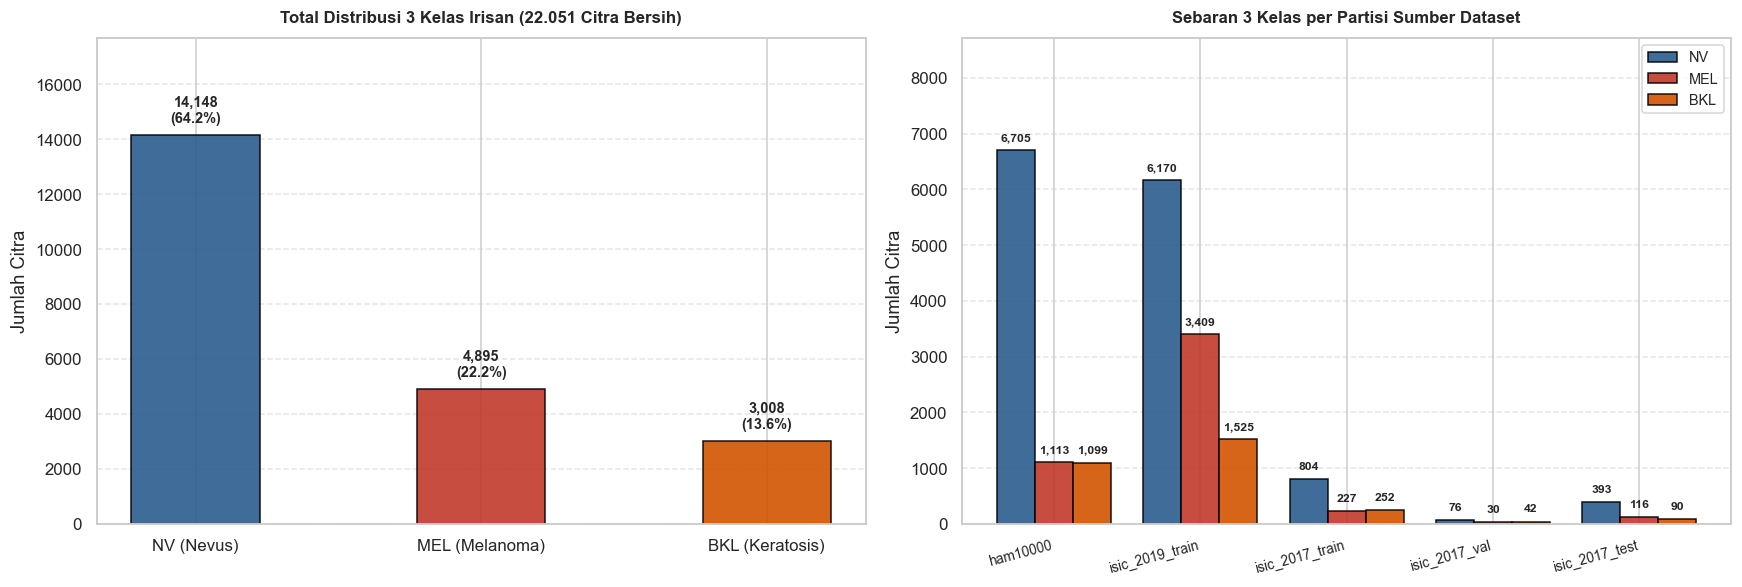

In [16]:
rekap_rows = []
sources_order = ['ham10000', 'isic_2019_train', 'isic_2017_train', 'isic_2017_val', 'isic_2017_test']

for src in sources_order:
    sub = df_3kelas_final[df_3kelas_final['source'] == src]
    tot = len(sub)
    if tot == 0:
        continue
    n_nv = len(sub[sub['harmonized_label'] == 'NV'])
    n_mel = len(sub[sub['harmonized_label'] == 'MEL'])
    n_bkl = len(sub[sub['harmonized_label'] == 'BKL'])
    
    rekap_rows.append({
        'Source Dataset': src,
        'Total Citra': f"{tot:,}",
        'NV (Nevus)': f"{n_nv:,} ({n_nv/tot*100:.1f}%)",
        'MEL (Melanoma)': f"{n_mel:,} ({n_mel/tot*100:.1f}%)",
        'BKL (Keratosis)': f"{n_bkl:,} ({n_bkl/tot*100:.1f}%)"
    })

tot_nv = len(df_3kelas_final[df_3kelas_final['harmonized_label'] == 'NV'])
tot_mel = len(df_3kelas_final[df_3kelas_final['harmonized_label'] == 'MEL'])
tot_bkl = len(df_3kelas_final[df_3kelas_final['harmonized_label'] == 'BKL'])

rekap_rows.append({
    'Source Dataset': 'TOTAL KESELURUHAN',
    'Total Citra': f"{total_akhir_3k:,}",
    'NV (Nevus)': f"{tot_nv:,} ({tot_nv/total_akhir_3k*100:.1f}%)",
    'MEL (Melanoma)': f"{tot_mel:,} ({tot_mel/total_akhir_3k*100:.1f}%)",
    'BKL (Keratosis)': f"{tot_bkl:,} ({tot_bkl/total_akhir_3k*100:.1f}%)"
})

df_rekap_3k = pd.DataFrame(rekap_rows)
display(df_rekap_3k)

# Visualisasi 2 Subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Total Distribusi
ax1 = axes[0]
classes_names = ['NV (Nevus)', 'MEL (Melanoma)', 'BKL (Keratosis)']
counts_classes = [tot_nv, tot_mel, tot_bkl]
colors_tri = ['#2b5c8f', '#c0392b', '#d35400']

bars1 = ax1.bar(classes_names, counts_classes, color=colors_tri, edgecolor='black', width=0.45, alpha=0.9)
ax1.set_title("Total Distribusi 3 Kelas Irisan (22.051 Citra Bersih)", fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel("Jumlah Citra")
ax1.set_ylim(0, max(counts_classes) * 1.25)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    h = bar.get_height()
    pct = h / total_akhir_3k * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        h + (max(counts_classes) * 0.025),
        f"{int(h):,}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=9.5, fontweight='bold'
    )

# 2. Perbandingan per Sumber Dataset
ax2 = axes[1]
datasets_list = [r['Source Dataset'] for r in rekap_rows if r['Source Dataset'] != 'TOTAL KESELURUHAN']
x = np.arange(len(datasets_list))
width = 0.26

nv_vals = [len(df_3kelas_final[(df_3kelas_final['source'] == s) & (df_3kelas_final['harmonized_label'] == 'NV')]) for s in datasets_list]
mel_vals = [len(df_3kelas_final[(df_3kelas_final['source'] == s) & (df_3kelas_final['harmonized_label'] == 'MEL')]) for s in datasets_list]
bkl_vals = [len(df_3kelas_final[(df_3kelas_final['source'] == s) & (df_3kelas_final['harmonized_label'] == 'BKL')]) for s in datasets_list]

rects_nv = ax2.bar(x - width, nv_vals, width=width, label='NV', color='#2b5c8f', edgecolor='black', alpha=0.9)
rects_mel = ax2.bar(x, mel_vals, width=width, label='MEL', color='#c0392b', edgecolor='black', alpha=0.9)
rects_bkl = ax2.bar(x + width, bkl_vals, width=width, label='BKL', color='#d35400', edgecolor='black', alpha=0.9)

max_val = max(max(nv_vals), max(mel_vals), max(bkl_vals))
ax2.set_ylim(0, max_val * 1.30)
ax2.set_xticks(x)
ax2.set_xticklabels(datasets_list, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel("Jumlah Citra")
ax2.set_title("Sebaran 3 Kelas per Partisi Sumber Dataset", fontsize=11, fontweight='bold', pad=10)
ax2.legend(fontsize=9.5)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for rect in rects_nv:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + (max_val * 0.02), f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold')

for rect in rects_mel:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + (max_val * 0.02), f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold')

for rect in rects_bkl:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + (max_val * 0.02), f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## Langkah 8: Ekspor Master Dataset Bersih
Menyimpan seluruh 22.051 baris data bersih hasil irisan 3 kelas ke file CSV master `Dataset/dataset_irisan_multiclass_final.csv`.

In [17]:
output_irisan_csv = os.path.join(ROOT, 'dataset_irisan_multiclass_final.csv')
cols_final = [
    'image_id',
    'source',
    'original_label',
    'harmonized_label',
    'target_multiclass',
    'class_name',
    'filepath'
]

df_3kelas_final[cols_final].to_csv(output_irisan_csv, index=False)

print(f"File master berhasil disimpan: {output_irisan_csv}")
print(f"Ukuran file: {os.path.getsize(output_irisan_csv) / (1024*1024):.2f} MB")
print(f"Total baris: {len(df_3kelas_final):,} citra")
print(f"Daftar kelas: 0=NV, 1=MEL, 2=BKL")

print("\nContoh 5 baris pertama file yang diekspor:")
display(pd.read_csv(output_irisan_csv).head(5))

File master berhasil disimpan: c:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_irisan_multiclass_final.csv
Ukuran file: 4.28 MB
Total baris: 22,051 citra
Daftar kelas: 0=NV, 1=MEL, 2=BKL

Contoh 5 baris pertama file yang diekspor:


,image_id,source,original_label,harmonized_label,target_multiclass,class_name,filepath
0,ISIC_0000000,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),c:\Users\ARII\Downloads\Data Understanding Isi...
1,ISIC_0000001,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),c:\Users\ARII\Downloads\Data Understanding Isi...
2,ISIC_0000002,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas),c:\Users\ARII\Downloads\Data Understanding Isi...
3,ISIC_0000003,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),c:\Users\ARII\Downloads\Data Understanding Isi...
4,ISIC_0000004,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas),c:\Users\ARII\Downloads\Data Understanding Isi...


## Langkah 9: Pembagian Data Bebas Kebocoran (Lesion-Aware Split 80:10:10)
Memetakan lesion_id pasien dan membagi data dengan StratifiedGroupKFold agar seluruh citra dari lesi yang sama selalu berada pada split yang sama (overlap lesi tepat 0).

In [18]:
# 1. Pemetaan lesion_id (HAM10000 + ISIC 2019)
ham_meta = pd.read_csv(os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'))[['image_id', 'lesion_id']]
isic19_meta = pd.read_csv(os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv'))[['image', 'lesion_id']].rename(columns={'image': 'image_id'})

lesion_dict = {}
for _, row in ham_meta.iterrows():
    lesion_dict[row['image_id']] = str(row['lesion_id'])
for _, row in isic19_meta.dropna(subset=['lesion_id']).iterrows():
    if row['image_id'] not in lesion_dict:
        lesion_dict[row['image_id']] = str(row['lesion_id'])

df_3kelas_final['lesion_id'] = df_3kelas_final['image_id'].map(lesion_dict).fillna(df_3kelas_final['image_id'])

print(f"Total citra dalam dataset              : {len(df_3kelas_final):,} citra")
print(f"Citra dengan kelompok lesi terdata     : {(df_3kelas_final['lesion_id'] != df_3kelas_final['image_id']).sum():,} citra")
print(f"Total lesi unik (grouping identifiers) : {df_3kelas_final['lesion_id'].nunique():,} lesi")

# 2. Pembagian data dengan StratifiedGroupKFold (10-fold -> 80:10:10)
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
splits = list(sgkf.split(df_3kelas_final, df_3kelas_final['target_multiclass'], groups=df_3kelas_final['lesion_id']))

test_idx = splits[0][1]
val_idx = splits[1][1]
train_idx = np.setdiff1d(np.arange(len(df_3kelas_final)), np.concatenate([test_idx, val_idx]))

df_3kelas_final['split'] = ''
df_3kelas_final.loc[train_idx, 'split'] = 'train'
df_3kelas_final.loc[val_idx, 'split'] = 'val'
df_3kelas_final.loc[test_idx, 'split'] = 'test'

# 3. Audit kebocoran lesi pasien
train_lesions = set(df_3kelas_final[df_3kelas_final['split'] == 'train']['lesion_id'])
val_lesions   = set(df_3kelas_final[df_3kelas_final['split'] == 'val']['lesion_id'])
test_lesions  = set(df_3kelas_final[df_3kelas_final['split'] == 'test']['lesion_id'])

leak_train_val  = len(train_lesions.intersection(val_lesions))
leak_train_test = len(train_lesions.intersection(test_lesions))
leak_val_test   = len(val_lesions.intersection(test_lesions))

print("\nHasil audit kebocoran lesi pasien:")
print(f"- Overlap Train <-> Val  : {leak_train_val} (Bebas kebocoran)")
print(f"- Overlap Train <-> Test : {leak_train_test} (Bebas kebocoran)")
print(f"- Overlap Val <-> Test   : {leak_val_test} (Bebas kebocoran)")
assert leak_train_val == 0 and leak_train_test == 0 and leak_val_test == 0, "Ditemukan kebocoran lesi!"
print("Status: Sukses 100% bebas kebocoran lesi pasien.")

# 4. Ekspor ke file CSV siap latih
cols_with_split = [
    'image_id', 'lesion_id', 'source', 'original_label', 
    'harmonized_label', 'target_multiclass', 'class_name', 'split', 'filepath'
]

df_3kelas_final[cols_with_split].to_csv(output_master_csv, index=False)
df_3kelas_final[df_3kelas_final['split'] == 'train'][cols_with_split].to_csv(output_train_csv, index=False)
df_3kelas_final[df_3kelas_final['split'] == 'val'][cols_with_split].to_csv(output_val_csv, index=False)
df_3kelas_final[df_3kelas_final['split'] == 'test'][cols_with_split].to_csv(output_test_csv, index=False)

print("\nRingkasan file yang disimpan:")
print(f"1. Master Dataset : {output_master_csv} ({len(df_3kelas_final):,} baris)")
print(f"2. Training Set   : {output_train_csv} ({len(df_3kelas_final[df_3kelas_final['split']=='train']):,} baris)")
print(f"3. Validation Set : {output_val_csv} ({len(df_3kelas_final[df_3kelas_final['split']=='val']):,} baris)")
print(f"4. Test Set       : {output_test_csv} ({len(df_3kelas_final[df_3kelas_final['split']=='test']):,} baris)")

Total citra dalam dataset              : 22,051 citra
Citra dengan kelompok lesi terdata     : 17,937 citra
Total lesi unik (grouping identifiers) : 13,817 lesi

Hasil audit kebocoran lesi pasien:
- Overlap Train <-> Val  : 0 (Bebas kebocoran)
- Overlap Train <-> Test : 0 (Bebas kebocoran)
- Overlap Val <-> Test   : 0 (Bebas kebocoran)
Status: Sukses 100% bebas kebocoran lesi pasien.


NameError: name 'output_master_csv' is not defined

## Langkah 10: Evaluasi Stratifikasi Split dan Karakteristik Fisik Citra
Memeriksa keseimbangan proporsi kelas pada subset data (Train, Val, Test) dan mendokumentasikan resolusi fisik citra sebagai acuan preprocessing.

Jumlah citra per kelas pada setiap subset:

harmonized_label,BKL,MEL,NV,All
,269,543,1391,2203
,2452,3902,11302,17656
,287,450,1455,2192
,3008,4895,14148,22051



Proporsi kelas (%) pada setiap subset:

harmonized_label,BKL,MEL,NV
,12.21,24.65,63.14
,13.89,22.10,64.01
,13.09,20.53,66.38


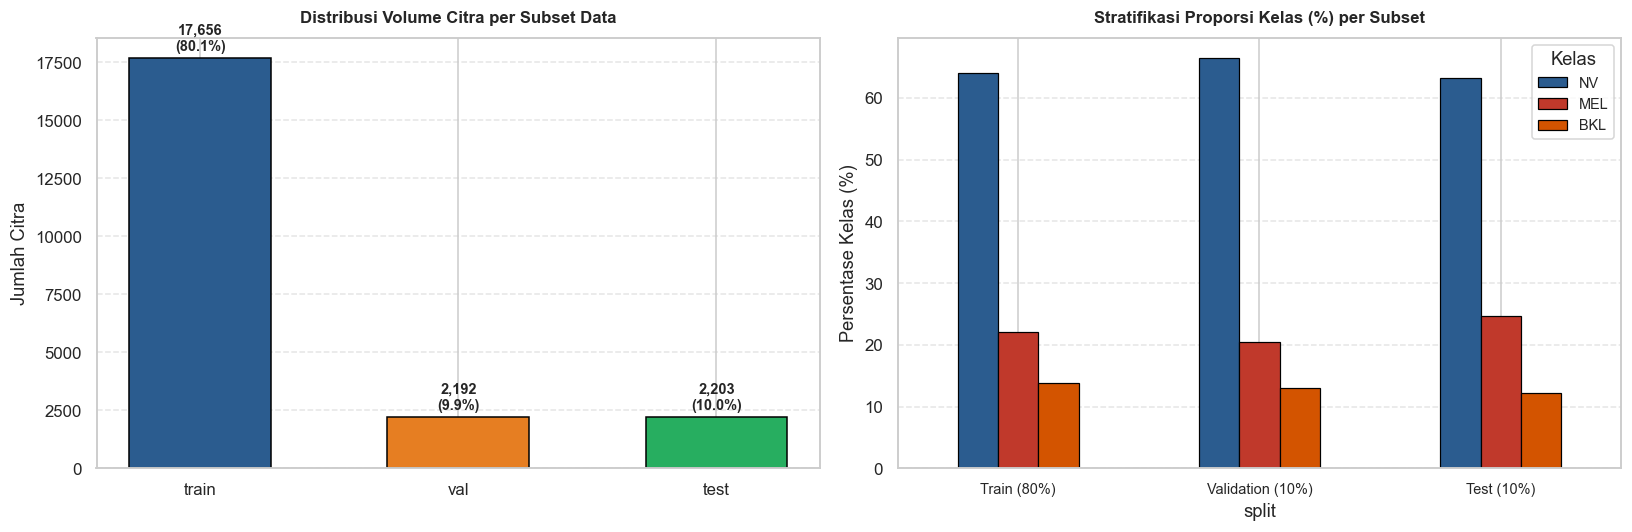


Sampling karakteristik resolusi fisik citra:

Source Dataset,Sample Image ID,Resolusi (Px),Aspek Rasio,Kanal Warna,Format File
isic_2019_train,ISIC_0000000,1022 x 767,1.33,RGB,JPEG
isic_2017_train,ISIC_0000017,1504 x 1129,1.33,RGB,JPEG
isic_2017_val,ISIC_0001769,3024 x 2016,1.50,RGB,JPEG
isic_2017_test,ISIC_0012086,4288 x 2848,1.51,RGB,JPEG
ham10000,ISIC_0024306,600 x 450,1.33,RGB,JPEG


In [ ]:
split_crosstab = pd.crosstab(df_3kelas_final['split'], df_3kelas_final['harmonized_label'], margins=True)
split_prop = pd.crosstab(df_3kelas_final['split'], df_3kelas_final['harmonized_label'], normalize='index') * 100

print("Jumlah citra per kelas pada setiap subset:")
display(split_crosstab)

print("\nProporsi kelas (%) pada setiap subset:")
display(split_prop.round(2))

# Visualisasi Evaluasi Split
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Volume Citra
split_counts = df_3kelas_final['split'].value_counts()[['train', 'val', 'test']]
colors_split = ['#2b5c8f', '#e67e22', '#27ae60']
bars = axes[0].bar(split_counts.index, split_counts.values, color=colors_split, width=0.55, edgecolor='black', linewidth=1.0)
axes[0].set_title('Distribusi Volume Citra per Subset Data', fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('Jumlah Citra')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for b in bars:
    yval = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2.0, yval + 200, f'{yval:,}\n({yval/len(df_3kelas_final)*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# 2. Proporsi Kelas
split_prop_plot = split_prop.drop(index='All', errors='ignore').loc[['train', 'val', 'test']][['NV', 'MEL', 'BKL']]
split_prop_plot.plot(kind='bar', ax=axes[1], color=['#2b5c8f', '#c0392b', '#d35400'], edgecolor='black', linewidth=0.8)
axes[1].set_title('Stratifikasi Proporsi Kelas (%) per Subset', fontsize=11, fontweight='bold', pad=10)
axes[1].set_ylabel('Persentase Kelas (%)')
axes[1].set_xticklabels(['Train (80%)', 'Validation (10%)', 'Test (10%)'], rotation=0, fontsize=9.5)
axes[1].legend(title='Kelas', labels=['NV', 'MEL', 'BKL'], fontsize=9.5)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Karakteristik Fisik Citra
sources_unique = df_3kelas_final['source'].unique()
sample_specs = []
for src in sources_unique:
    row = df_3kelas_final[df_3kelas_final['source'] == src].iloc[0]
    try:
        with Image.open(row['filepath']) as img:
            sample_specs.append({
                'Source Dataset': src,
                'Sample Image ID': row['image_id'],
                'Resolusi (Px)': f"{img.size[0]} x {img.size[1]}",
                'Aspek Rasio': f"{img.size[0]/img.size[1]:.2f}",
                'Kanal Warna': img.mode,
                'Format File': img.format
            })
    except Exception as e:
        pass

print("\nSampling karakteristik resolusi fisik citra:")
display(pd.DataFrame(sample_specs))

## Langkah 11: Kesimpulan Data Preparation dan Kesiapan Modeling
Rangkuman hasil tahap Data Preparation:
1. **Total Citra Siap Latih:** Diperoleh 22.051 citra bersih bebas duplikat yang terbagi menjadi Train (17.656 citra), Validation (2.192 citra), dan Test (2.203 citra).
2. **Pencegahan Kebocoran Data:** 100% bebas kebocoran lesi pasien (overlap lesi antar-subset = 0) berkat algoritma StratifiedGroupKFold berbasis lesion_id.
3. **Proporsi Kelas Konsisten:** Distribusi kelas konsisten di setiap subset (NV ~64%, MEL ~22%, BKL ~13%).
4. **File CSV Tersimpan Rapi:** Dataset siap digunakan langsung oleh DataLoader PyTorch pada notebook baseline_modeling_3kelas.ipynb atau skrip train_baseline.py.